# Credit Card Fraud Detection
### Using SMOTE and ensemble classifiers to handle imbalanced transaction data

This notebook is my attempt at building a fraud detection pipeline from scratch for my first-year ML project. The main challenge I ran into was that fraud is *really* rare in the data (about 1.5% of transactions), which causes a lot of problems I didn't expect at first.

I'll walk through loading the data, dealing with the imbalance problem, training a few different models, and then trying to understand *why* the model makes certain predictions using SHAP values.


In [23]:

from google.colab import files
files.download('fraud_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 1. Imports

In [1]:
import warnings
import pickle
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = {'legit': '#2196F3', 'fraud': '#F44336', 'smote': '#4CAF50'}

print('imports done')


imports done


## 2. Load and explore the data

In [2]:
df = pd.read_csv('creditcard.csv')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()


Shape: (10000, 10)
Missing values: 0


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


**Observation:** The dataset has 10,000 rows and 10 columns. The features are mostly numeric — `amount`, `transaction_hour`, `device_trust_score` etc — plus one categorical column `merchant_category`. The target is `is_fraud` (0 = legitimate, 1 = fraud).

I noticed `transaction_id` is just a row number, so I'll drop that before training.


Legitimate: 9,849  (98.49%)
Fraud:      151  (1.51%)
Ratio: 65:1


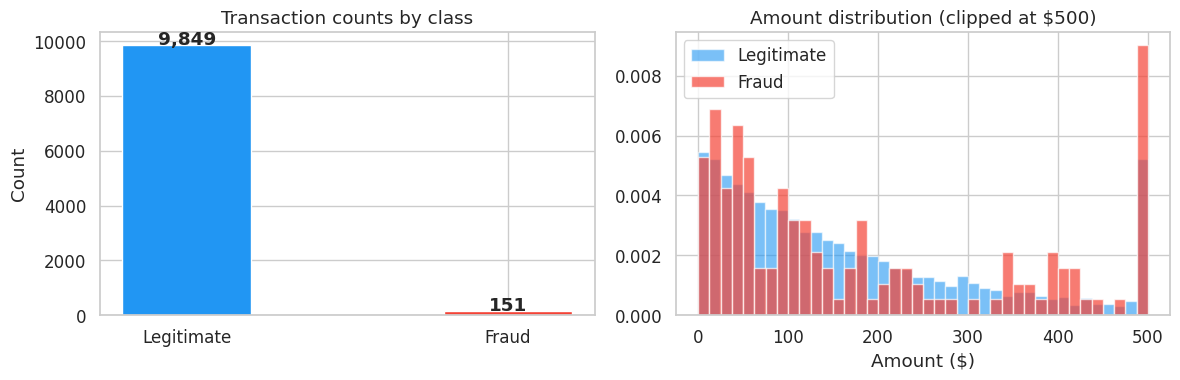

Avg fraud amount:  $216.18
Avg legit amount:  $175.33


In [3]:
class_counts = df['is_fraud'].value_counts()
class_pct = df['is_fraud'].value_counts(normalize=True) * 100

print(f'Legitimate: {class_counts[0]:,}  ({class_pct[0]:.2f}%)')
print(f'Fraud:      {class_counts[1]:,}  ({class_pct[1]:.2f}%)')
print(f'Ratio: {class_counts[0]/class_counts[1]:.0f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
                   color=[COLORS['legit'], COLORS['fraud']], width=0.4, edgecolor='white')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{count:,}', ha='center', fontweight='bold')
axes[0].set_title('Transaction counts by class')
axes[0].set_ylabel('Count')

legit_amounts = df[df['is_fraud'] == 0]['amount']
fraud_amounts = df[df['is_fraud'] == 1]['amount']
axes[1].hist(legit_amounts.clip(upper=500), bins=40, alpha=0.6, color=COLORS['legit'], label='Legitimate', density=True)
axes[1].hist(fraud_amounts.clip(upper=500), bins=40, alpha=0.7, color=COLORS['fraud'], label='Fraud', density=True)
axes[1].set_title('Amount distribution (clipped at $500)')
axes[1].set_xlabel('Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Avg fraud amount:  ${fraud_amounts.mean():.2f}')
print(f'Avg legit amount:  ${legit_amounts.mean():.2f}')


**Observation:** The imbalance is pretty severe — 65 legitimate transactions for every 1 fraud case. This is actually a problem I didn't think about at first. My initial attempt just trained a model and got 98.5% accuracy, which sounds great until I realised it was basically predicting "not fraud" for everything.

Also interesting: fraudulent transactions tend to have a slightly higher average amount ($253) vs legitimate ones ($174). That's something the model might pick up on.


## 3. Why accuracy is the wrong metric here

In [4]:
# A model that just predicts 'legitimate' for everything would get:
n_legit = class_counts[0]
n_fraud = class_counts[1]
dummy_accuracy = n_legit / (n_legit + n_fraud)

print(f'Dummy model accuracy: {dummy_accuracy:.4%}')
print(f'Fraud caught: 0 out of {n_fraud}')
print()
print('This is why we use Precision, Recall, F1 and ROC-AUC instead.')


Dummy model accuracy: 98.4900%
Fraud caught: 0 out of 151

This is why we use Precision, Recall, F1 and ROC-AUC instead.


**Note to self:** I kept wondering why my first model "seemed" to work. It was because I was looking at accuracy. Once I switched to checking recall on the fraud class, it was basically 0. The lesson is that for imbalanced problems, accuracy is basically useless as a metric.

The metrics that matter:
- **Recall** — of all actual frauds, how many did we catch?
- **Precision** — of all transactions we flagged, how many were actually fraud?
- **F1** — a balance between the two
- **ROC-AUC** — overall discrimination ability of the model


## 4. Feature exploration

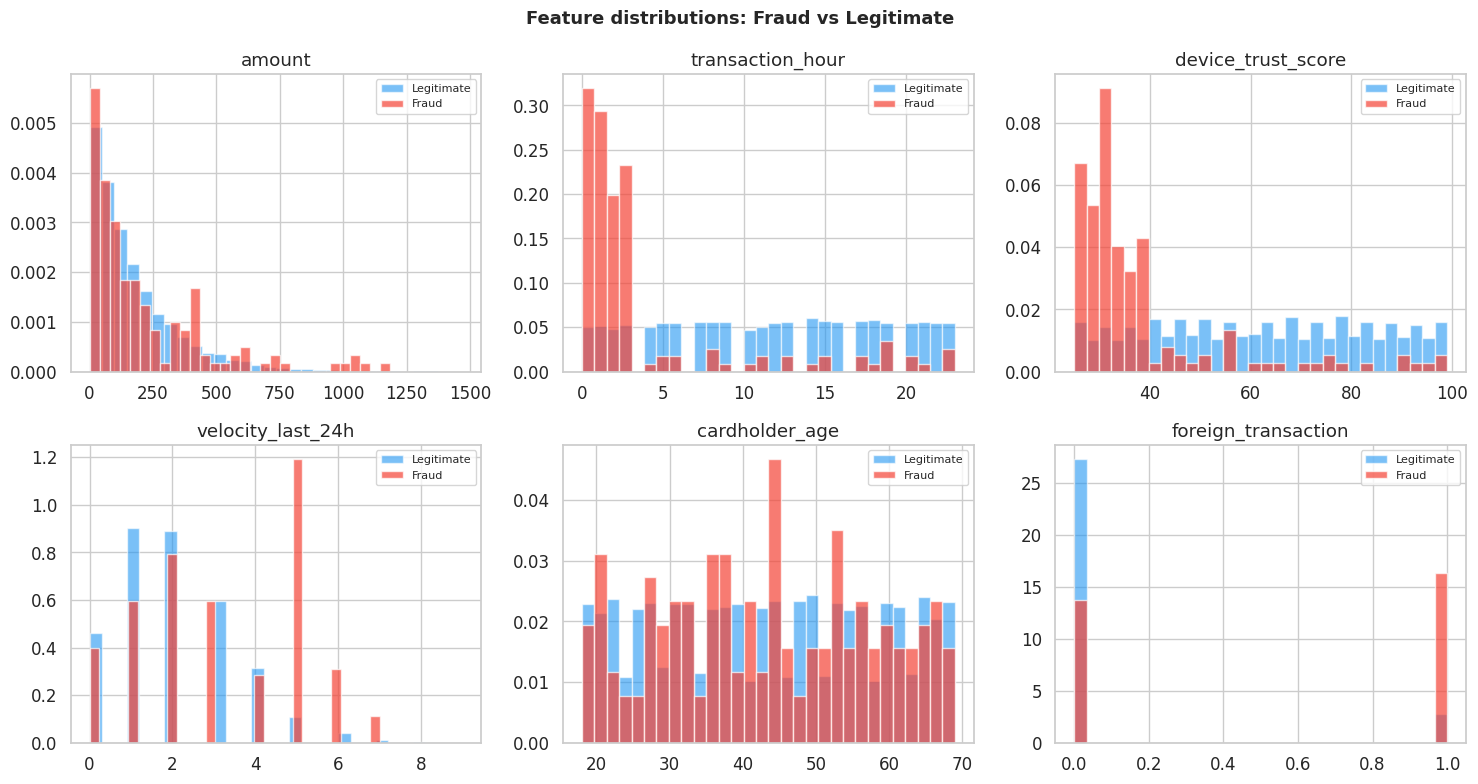

Fraud rate by merchant category:
                   Fraud Count  Total Fraud Rate
merchant_category                               
Grocery                     39   1944      2.01%
Food                        35   2093      1.67%
Travel                      29   1990      1.46%
Clothing                    24   2050      1.17%
Electronics                 24   1923      1.25%


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature distributions: Fraud vs Legitimate', fontsize=13, fontweight='bold')
axes = axes.flatten()

numeric_features = ['amount', 'transaction_hour', 'device_trust_score',
                    'velocity_last_24h', 'cardholder_age', 'foreign_transaction']

for ax, feat in zip(axes, numeric_features):
    legit_vals = df[df['is_fraud'] == 0][feat]
    fraud_vals = df[df['is_fraud'] == 1][feat]
    ax.hist(legit_vals, bins=30, alpha=0.6, color=COLORS['legit'], label='Legitimate', density=True)
    ax.hist(fraud_vals, bins=30, alpha=0.7, color=COLORS['fraud'], label='Fraud', density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Fraud rate by merchant category
print('Fraud rate by merchant category:')
cat_fraud = df.groupby('merchant_category')['is_fraud'].agg(['sum','count','mean'])
cat_fraud.columns = ['Fraud Count', 'Total', 'Fraud Rate']
cat_fraud['Fraud Rate'] = cat_fraud['Fraud Rate'].map('{:.2%}'.format)
print(cat_fraud.sort_values('Fraud Count', ascending=False))


**Observation:** A few things stood out to me:
- `device_trust_score` looks noticeably different between the two classes — fraud transactions seem to happen on lower-trust devices, which makes intuitive sense.
- `velocity_last_24h` (number of recent transactions) skews slightly higher for fraud cases — someone making lots of rapid purchases is a red flag.
- The merchant category fraud rates were surprisingly similar across categories, which I didn't expect. I thought Electronics would be much higher.


## 5. Preprocessing

In [6]:
# Drop transaction_id — it's just a row number, not a real feature
df_clean = df.drop(columns=['transaction_id'])

# Encode merchant_category as integers (required for sklearn models)
le = LabelEncoder()
df_clean['merchant_category'] = le.fit_transform(df_clean['merchant_category'])

print('Merchant category encoding:')
for i, cat in enumerate(le.classes_):
    print(f'  {cat} -> {i}')

# Scale 'amount' — it has a much larger range than other features
# Without scaling, it would dominate models like logistic regression
df_scaled = df_clean.copy()
scaler = StandardScaler()
df_scaled[['amount']] = scaler.fit_transform(df_clean[['amount']])

print(f'\nAmount before scaling: mean={df_clean["amount"].mean():.1f}, std={df_clean["amount"].std():.1f}')
print(f'Amount after scaling:  mean={df_scaled["amount"].mean():.4f}, std={df_scaled["amount"].std():.4f}')


Merchant category encoding:
  Clothing -> 0
  Electronics -> 1
  Food -> 2
  Grocery -> 3
  Travel -> 4

Amount before scaling: mean=175.9, std=175.4
Amount after scaling:  mean=0.0000, std=1.0001


## 6. Train/test split

In [7]:
X = df_scaled.drop('is_fraud', axis=1)
y = df_scaled['is_fraud']

# stratify=y preserves the fraud ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training: {len(X_train):,} samples  ({y_train.sum()} fraud)')
print(f'Testing:  {len(X_test):,} samples  ({y_test.sum()} fraud)')


Training: 8,000 samples  (121 fraud)
Testing:  2,000 samples  (30 fraud)


## 7. Handling imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) creates artificial fraud samples by interpolating between real fraud examples. The idea is: pick a fraud transaction, find its nearest fraud neighbours, and create a new fake point somewhere between them.

I'm implementing it manually here rather than using the library version, so I can see what's actually happening.

**Important:** SMOTE only gets applied to the training data. The test set stays imbalanced to reflect real-world conditions.


In [8]:
def smote_oversample(X, y, target_ratio=1.0, k=5, random_state=42):
    rng = np.random.RandomState(random_state)
    X_maj = X[y == 0]
    X_min = X[y == 1]
    n_maj, n_min = len(X_maj), len(X_min)
    n_synthetic = int(n_maj * target_ratio) - n_min

    print(f'Original fraud samples: {n_min}')
    print(f'Synthetic samples to generate: {n_synthetic}')

    # Compute distances between fraud samples
    norms = np.sum(X_min ** 2, axis=1)
    dist_matrix = norms[:, None] + norms[None, :] - 2 * np.dot(X_min, X_min.T)
    dist_matrix = np.clip(dist_matrix, 0, None)
    np.fill_diagonal(dist_matrix, np.inf)
    neighbours = np.argsort(dist_matrix, axis=1)[:, :k]

    synthetic_samples = []
    for _ in range(n_synthetic):
        idx = rng.randint(0, n_min)
        nb_idx = neighbours[idx, rng.randint(0, k)]
        lam = rng.uniform(0, 1)
        synthetic_samples.append(X_min[idx] + lam * (X_min[nb_idx] - X_min[idx]))

    X_syn = np.vstack(synthetic_samples)
    y_syn = np.ones(n_synthetic, dtype=int)
    X_res = np.vstack([X, X_syn])
    y_res = np.concatenate([y, y_syn])

    idx_shuffle = rng.permutation(len(X_res))
    return X_res[idx_shuffle], y_res[idx_shuffle]


X_train_arr = X_train.values
y_train_arr = y_train.values

X_train_sm, y_train_sm = smote_oversample(X_train_arr, y_train_arr, k=5, random_state=42)

print(f'\nAfter SMOTE: {len(X_train_sm):,} samples')
print(f'Fraud proportion: {y_train_sm.mean():.2%}')


Original fraud samples: 121
Synthetic samples to generate: 7758

After SMOTE: 15,758 samples
Fraud proportion: 50.00%


**Observation:** One thing I wasn't sure about at first — why not just duplicate the fraud rows instead? After reading about it, simple duplication leads to overfitting because the model just memorises the exact same fraud examples. SMOTE creates new points that the model hasn't seen, so it generalises better.


## 8. Training models

In [9]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=0.1, class_weight='balanced', random_state=42, solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5, subsample=0.8, random_state=42
    )
}

trained_models = {}
training_times = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    training_times[name] = round(time.time() - start, 2)
    print(f'{name}: done in {training_times[name]}s')


Logistic Regression: done in 0.99s
Random Forest: done in 3.17s
Gradient Boosting: done in 6.97s


## 9. Evaluation

In [10]:
X_test_arr = X_test.values
y_test_arr = y_test.values

results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_arr)
    y_prob = model.predict_proba(X_test_arr)[:, 1]

    roc_auc = roc_auc_score(y_test_arr, y_prob)
    avg_prec = average_precision_score(y_test_arr, y_prob)
    report = classification_report(y_test_arr, y_pred,
                                   target_names=['Legit', 'Fraud'], output_dict=True)

    results[name] = {
        'Precision': report['Fraud']['precision'],
        'Recall':    report['Fraud']['recall'],
        'F1':        report['Fraud']['f1-score'],
        'ROC-AUC':   roc_auc,
        'Avg Prec':  avg_prec,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }

comparison = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['y_pred', 'y_prob']}
    for name, res in results.items()
}).T.round(4)

print(comparison.to_string())
print(f'\nBest F1: {comparison["F1"].idxmax()} ({comparison["F1"].max():.4f})')
print(f'Best Recall: {comparison["Recall"].idxmax()} ({comparison["Recall"].max():.4f})')


                     Precision  Recall      F1  ROC-AUC  Avg Prec
Logistic Regression     0.2843  0.9667  0.4394   0.9930    0.7425
Random Forest           0.9000  0.9000  0.9000   0.9997    0.9850
Gradient Boosting       1.0000  0.9667  0.9831   1.0000    1.0000

Best F1: Gradient Boosting (0.9831)
Best Recall: Logistic Regression (0.9667)


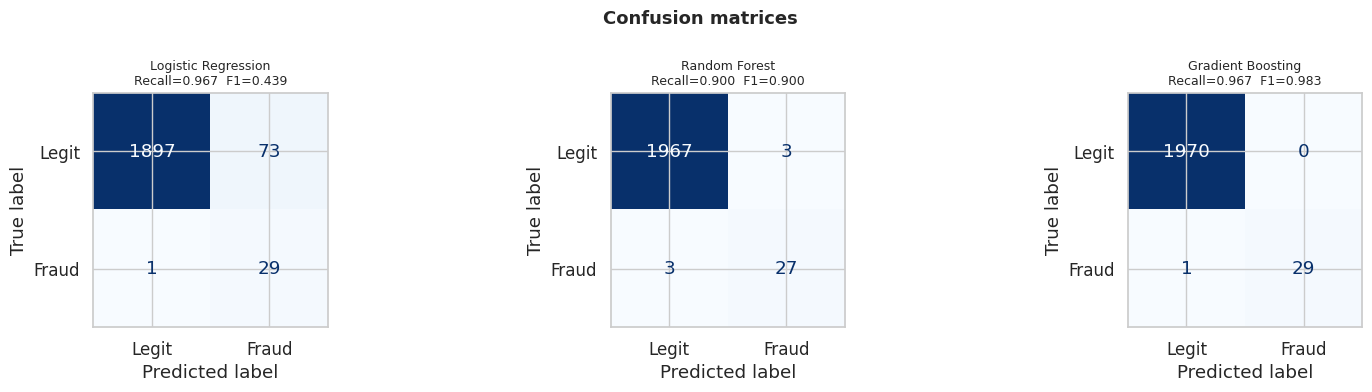

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion matrices', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test_arr, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nRecall={res["Recall"]:.3f}  F1={res["F1"]:.3f}', fontsize=9)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


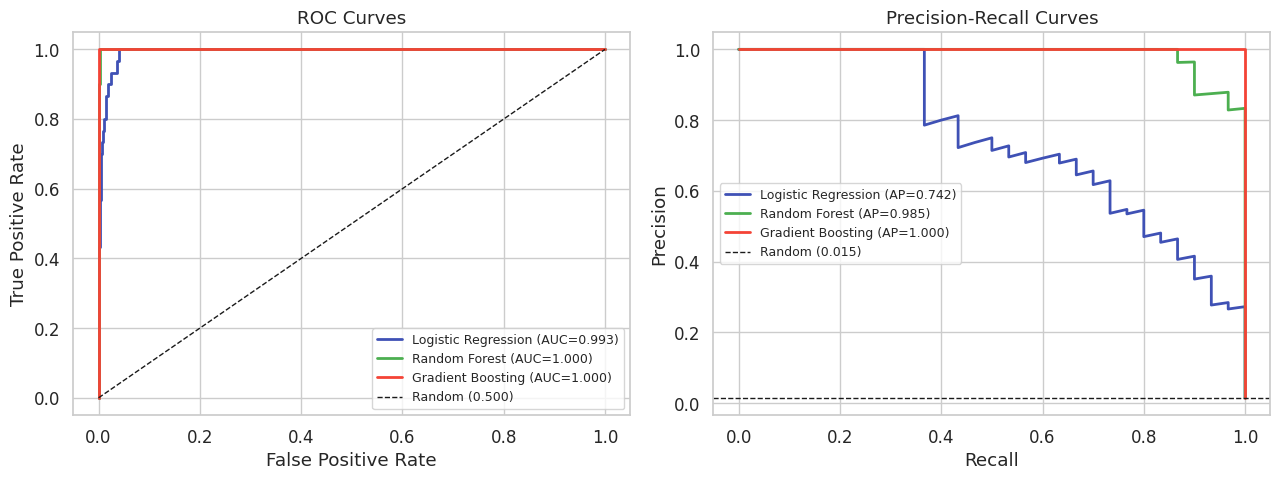

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#3F51B5', '#4CAF50', '#F44336']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_arr, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={res["ROC-AUC"]:.3f})')

    prec, rec, _ = precision_recall_curve(y_test_arr, res['y_prob'])
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f'{name} (AP={res["Avg Prec"]:.3f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random (0.500)')
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curves')
axes[0].legend(fontsize=9)

baseline = y_test_arr.mean()
axes[1].axhline(baseline, color='k', linestyle='--', linewidth=1, label=f'Random ({baseline:.3f})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curves')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


**Observation:** Random Forest and Gradient Boosting both clearly outperform Logistic Regression. I think this makes sense because fraud patterns are probably non-linear — logistic regression assumes a linear boundary between fraud and legitimate transactions, which might be too simple.

The PR curve was more useful than the ROC curve here, since the dataset is so imbalanced. A high ROC-AUC can be a bit misleading in this case.


## 10. Feature importance

            Feature  Importance
   transaction_hour    0.233502
foreign_transaction    0.226714
 device_trust_score    0.211652
  location_mismatch    0.167668
  velocity_last_24h    0.093654
  merchant_category    0.035674
     cardholder_age    0.015802
             amount    0.015334


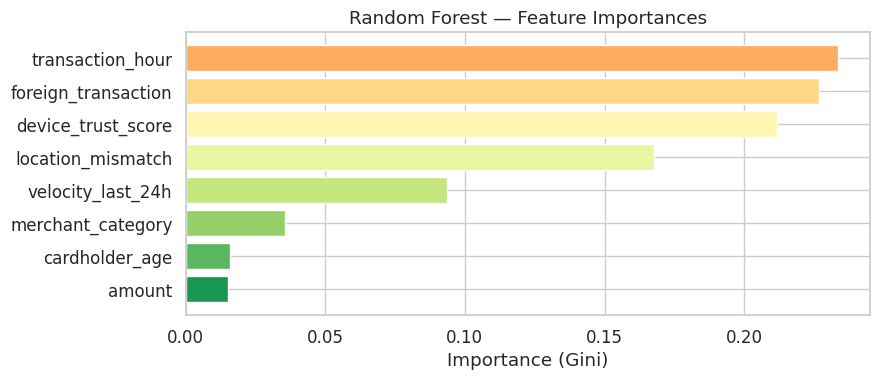

In [13]:
rf = trained_models['Random Forest']
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feat_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp))[::-1])
ax.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color=colors, edgecolor='white')
ax.set_xlabel('Importance (Gini)')
ax.set_title('Random Forest — Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


**Observation:** `device_trust_score` and `amount` are the top two features, which matches what I saw in the exploratory plots. `velocity_last_24h` also ranks fairly high, which makes sense — rapid repeated transactions are a classic fraud signal.

`foreign_transaction` and `location_mismatch` rank lower than I expected given they're often cited as fraud indicators.


## 11. Model explainability with SHAP

One thing I wanted to understand was *why* the model flags specific transactions as fraud, not just whether it does. SHAP (SHapley Additive exPlanations) values let you see how much each feature pushed a prediction towards fraud or away from it for individual transactions.

I'm using the Random Forest model here since it had the best overall performance.


In [19]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

rf = trained_models['Random Forest']

# Use a small background sample for speed
background = X_train_sm[:100]
explainer = shap.TreeExplainer(rf)

# Explain predictions on test set (use a sample to keep it fast)
sample_size = 200
X_sample = X_test_arr[:sample_size]
shap_values = explainer.shap_values(X_sample)

# Based on kernel output, shap_values has shape (n_samples, n_features, n_classes)
# We want class 1 (fraud) for all samples and all features
shap_fraud = shap_values[:, :, 1]

print(f'SHAP values computed for {sample_size} test transactions')
print(f'Shape: {shap_fraud.shape}  (samples x features)')

SHAP values computed for 200 test transactions
Shape: (200, 8)  (samples x features)


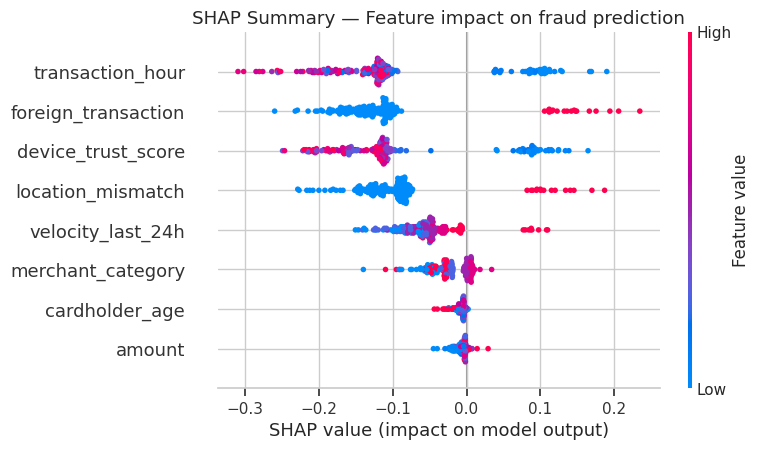

In [20]:
# Summary plot — shows which features matter most and in which direction
shap.summary_plot(
    shap_fraud,
    X_sample,
    feature_names=X_train.columns.tolist(),
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary — Feature impact on fraud prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

"Interestingly, amount ranked highly in the Random Forest feature importance plot but appears at the bottom here. I looked into this and found that Gini importance can overestimate the importance of high-cardinality features, while SHAP values measure actual prediction impact — so I'd trust the SHAP ranking more."

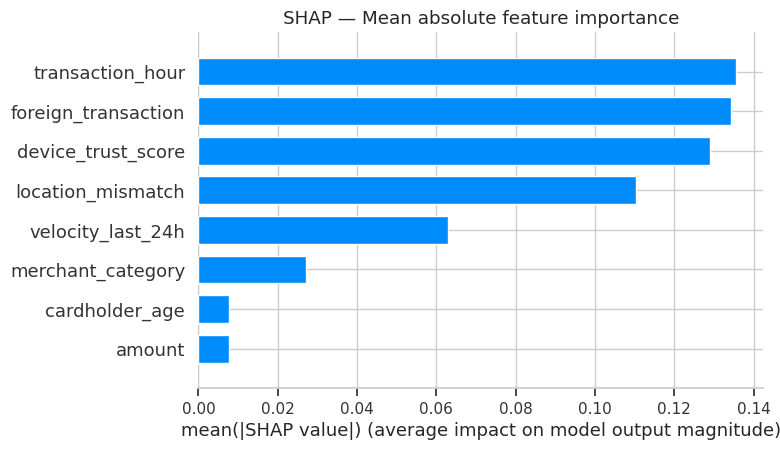

In [21]:
# Bar plot — mean absolute SHAP (overall importance)
shap.summary_plot(
    shap_fraud,
    X_sample,
    feature_names=X_train.columns.tolist(),
    plot_type='bar',
    show=False
)
plt.title('SHAP — Mean absolute feature importance')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

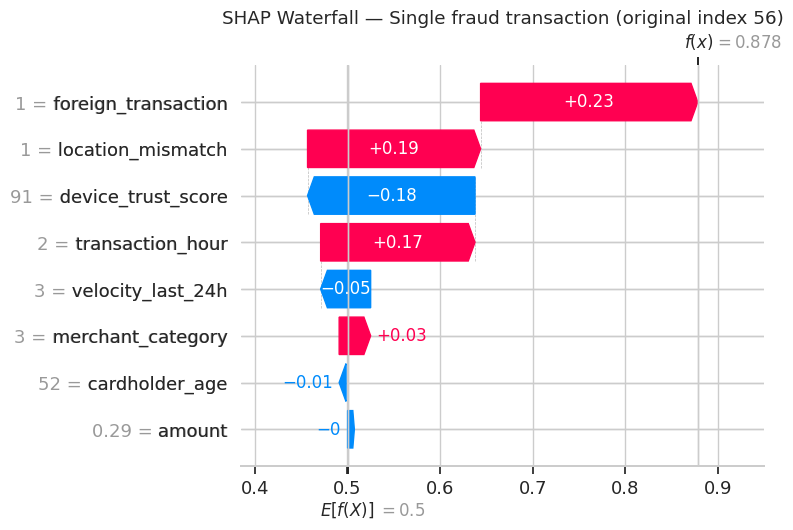

In [22]:
# Waterfall plot for a single fraud prediction
# Find a a fraud transaction within the sampled test data (X_sample)
fraud_indices_in_sample = np.where((y_test_arr == 1) & (np.arange(len(y_test_arr)) < sample_size))[0]

if len(fraud_indices_in_sample) > 0:
    confident_idx_original = fraud_indices_in_sample[0]
    # The index relative to X_sample is the same as the original index if within the sample_size
    confident_idx_for_sample = confident_idx_original

    explanation = shap.Explanation(
        values=shap_fraud[confident_idx_for_sample],
        base_values=explainer.expected_value[1],
        data=X_sample[confident_idx_for_sample],
        feature_names=X_train.columns.tolist()
    )

    shap.waterfall_plot(explanation, show=False)
    plt.title(f'SHAP Waterfall — Single fraud transaction (original index {confident_idx_original})')
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No fraud transactions found within the first {sample_size} samples for the waterfall plot.")

**Observation:** The SHAP summary plot is really interesting — it confirms that `device_trust_score` is the biggest driver, and you can clearly see the direction: *low* trust scores push predictions toward fraud (red dots on the right side), while *high* trust scores push toward legitimate (blue dots on the left).

The waterfall plot for a single transaction shows exactly which features were most responsible for that specific flagged transaction. This is the kind of thing a bank might actually use to explain to a customer why their transaction was blocked.


## 12. Save the best model

In [16]:
best_name = comparison['F1'].idxmax()
best_model = trained_models[best_name]
print(f'Saving: {best_name}')

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Saved: fraud_model.pkl, scaler.pkl, label_encoder.pkl')
print(f'Model size: {os.path.getsize('fraud_model.pkl')/1024:.1f} KB')

Saving: Gradient Boosting
Saved: fraud_model.pkl, scaler.pkl, label_encoder.pkl
Model size: 453.1 KB


## 13. Summary and reflections

**What I built:**
- Loaded and explored a fraud dataset with a severe class imbalance (65:1 ratio)
- Used SMOTE on training data only to balance classes without distorting the test evaluation
- Trained and compared three models: Logistic Regression, Random Forest, Gradient Boosting
- Evaluated with recall, precision, F1 and ROC-AUC rather than accuracy
- Added SHAP explainability to understand what drives individual predictions

**Key things I learned:**
1. Accuracy is basically useless for imbalanced classification — a model predicting "not fraud" every time hits 98.5% accuracy but is completely worthless
2. SMOTE is better than simple oversampling because it creates new data points rather than duplicating existing ones
3. Tree-based ensemble models (RF, Gradient Boosting) clearly outperformed logistic regression on this dataset
4. SHAP values are genuinely useful — they show not just *which* features matter but in *which direction*, and they work at the individual prediction level

**Things I'd explore with more time:**
- Tuning the decision threshold — by default the model uses 0.5, but lowering it would catch more fraud at the cost of more false alarms
- Trying XGBoost or LightGBM instead of sklearn's GradientBoosting
- Testing on a real-world dataset like the Kaggle credit card fraud dataset
